Proseggisi gia sigkrisi: 
- parsarw to label.txt me ta ground truth Bbox
- croparw to ground truth kai to dinw sto classifier
- vriskw to predicted bbox tou yolo me highest IOU me to gt bbox
  - if IOU > threshold: compare the classes (threshold = 0.5 ?)
  - if not: false negative
- pairnw to predicted cls tou yolo gi auto to predicted bbox
- sigkrinw ton classifier me to cls tou predicted apo to yolo bbox

In [1]:
from pathlib import Path
from dataclasses import dataclass
import numpy as np
from itertools import islice
import matplotlib.pyplot as plt
from ultralytics import YOLO
import torch
import torch.nn as nn
from torchvision.transforms import v2
import mlflow
import mlflow.pytorch

device = torch.device("cuda:0")

ROOT = Path.home() / Path("BLUEBERRY_DATA/datasets/dataset-c834a7b7/images")
tst_img = ROOT / "c834a7b7-4bbd-4791-98c0-9d2d8123d60a_R_00000443.png"
detector = YOLO("yolo_vs_classifier_v1.pt")

# ==========================================================
# LOAD classifier model
tracking_uri = Path("../experiments/mlflow.db").resolve()
mlflow.set_tracking_uri(f"sqlite:///{tracking_uri}")
run_id = "531b469fcd5f49ca86d611789277b437"
classifier = mlflow.pytorch.load_model(f"runs:/{run_id}/best_model")
classifier.eval()
# ==========================================================

inference_transform = v2.Compose([
  v2.ToImage(),
  v2.Resize((64,64)),
  v2.ToDtype(torch.float32, scale=True),
  # v2.Normalize(mean=, std=) # depends on which model i choose , where it was trained
])

/home/kpetrakis/ml-sandbox/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [80]:
# # dir(boxes)
# # names = result.names
# # img = result.orig_img # np.array (H,W,3)
# # plt.imshow(img)
# # plt.show()
# boxes = result.boxes
# boxes.xyxy, boxes.conf, boxes.cls


image 1/1 /home/kpetrakis/BLUEBERRY_DATA/datasets/dataset-c834a7b7/images/c834a7b7-4bbd-4791-98c0-9d2d8123d60a_R_00000443.png: 512x384 25 greens, 1 pink, 3 blues, 7.5ms
Speed: 8.8ms preprocess, 7.5ms inference, 0.7ms postprocess per image at shape (1, 3, 512, 384)
number of Detections: 29
yolo predicted class: 2 (67.13) classifier: 2 (99.67)


/home/kpetrakis/ml-sandbox/.venv/lib/python3.10/site-packages/torch/nn/modules/module.py:1739: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)


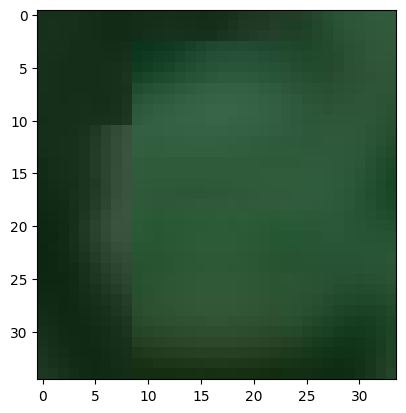

yolo predicted class: 2 (58.45) classifier: 2 (98.83)


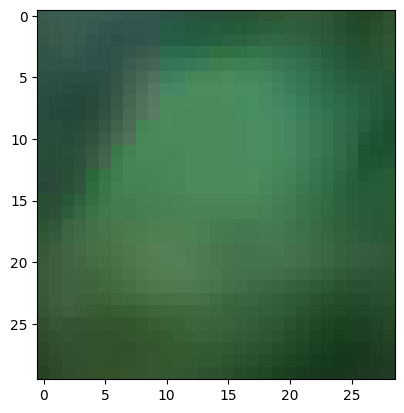

yolo predicted class: 5 (55.49) classifier: 2 (99.96)


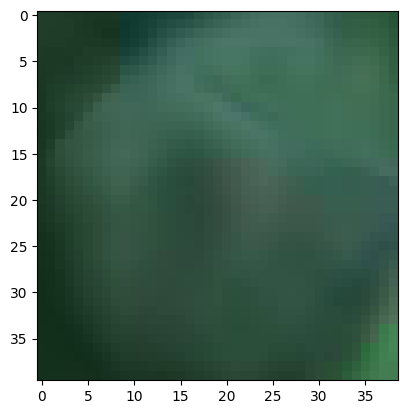

yolo predicted class: 3 (54.55) classifier: 2 (99.57)


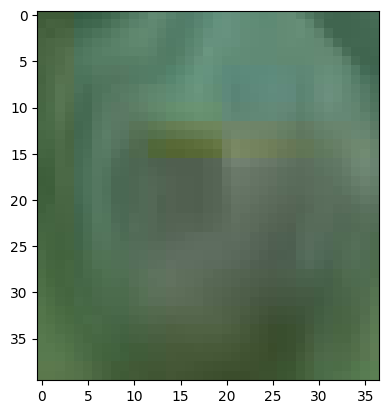

yolo predicted class: 5 (53.87) classifier: 2 (99.86)


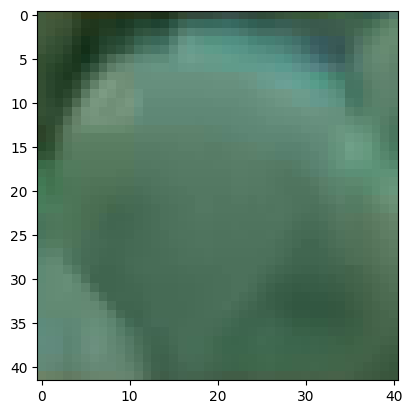

yolo predicted class: 2 (53.72) classifier: 2 (99.91)


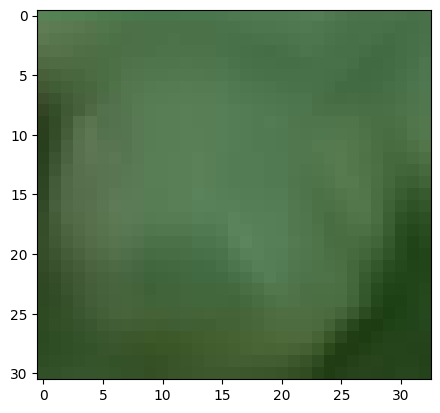

yolo predicted class: 2 (53.35) classifier: 2 (91.99)


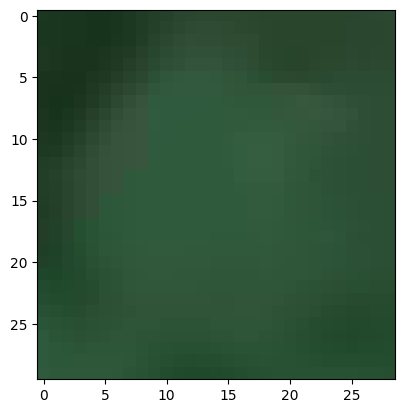

yolo predicted class: 2 (52.41) classifier: 2 (99.92)


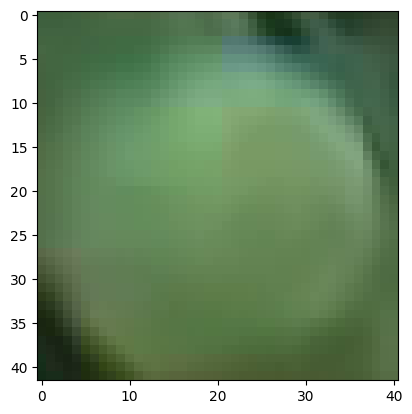

yolo predicted class: 2 (52.13) classifier: 2 (84.41)


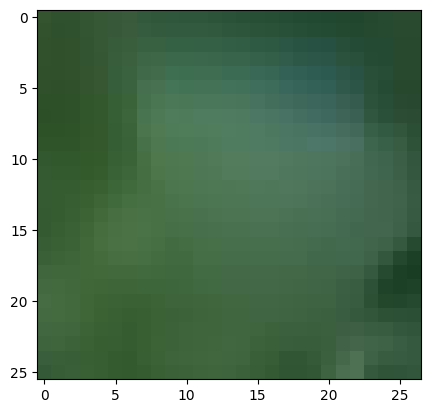

yolo predicted class: 2 (49.59) classifier: 2 (60.34)


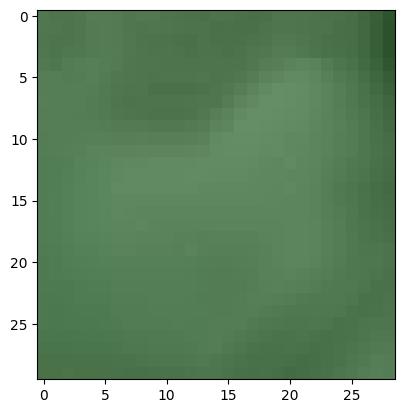

yolo predicted class: 5 (48.91) classifier: 2 (89.28)


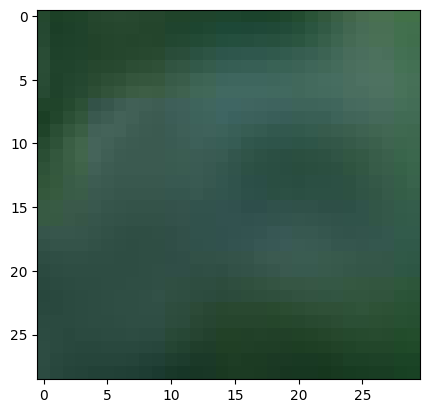

yolo predicted class: 2 (46.89) classifier: 2 (97.88)


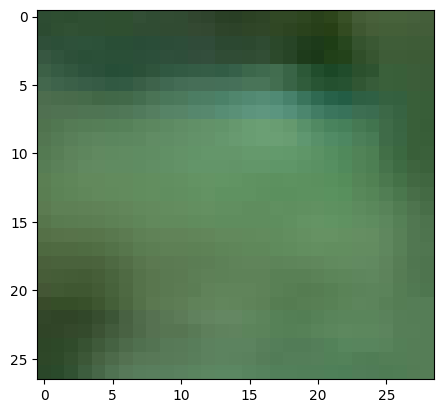

yolo predicted class: 2 (46.80) classifier: 2 (78.30)


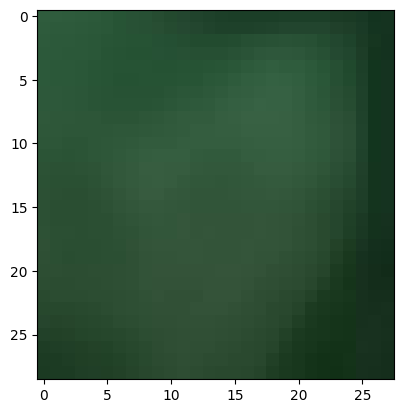

yolo predicted class: 2 (44.93) classifier: 2 (50.46)


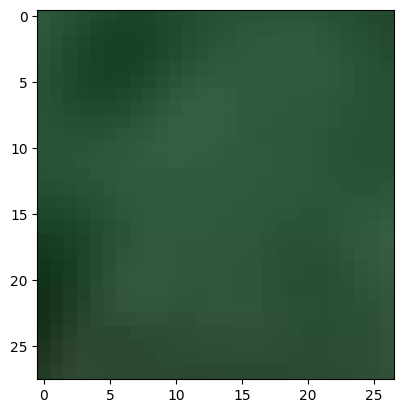

yolo predicted class: 2 (42.83) classifier: 2 (98.26)


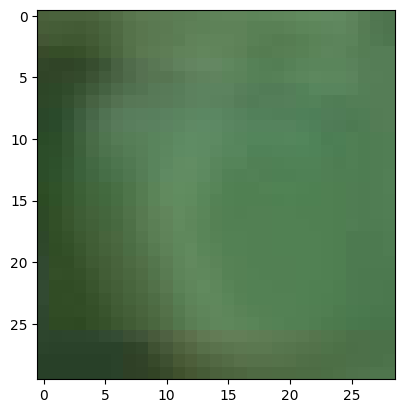

yolo predicted class: 2 (42.02) classifier: 2 (49.99)


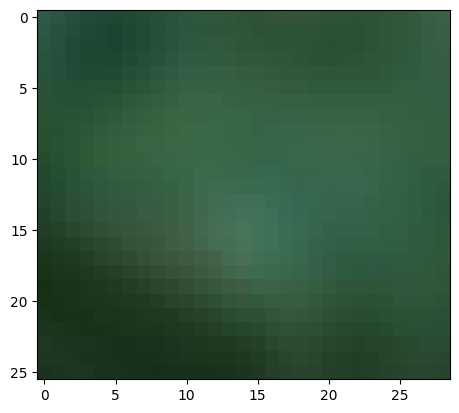

yolo predicted class: 2 (38.05) classifier: 2 (97.29)


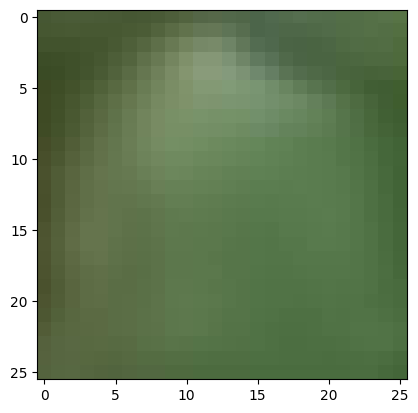

yolo predicted class: 2 (37.98) classifier: 2 (63.39)


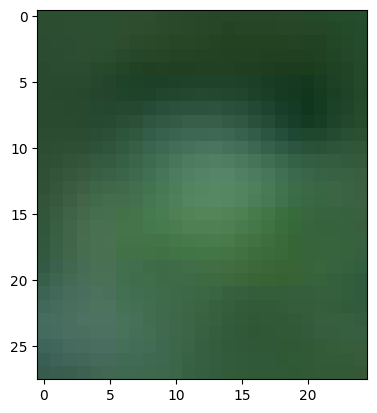

yolo predicted class: 2 (36.56) classifier: 2 (99.84)


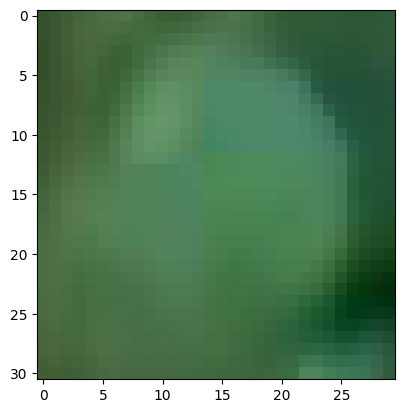

yolo predicted class: 2 (35.37) classifier: 2 (99.96)


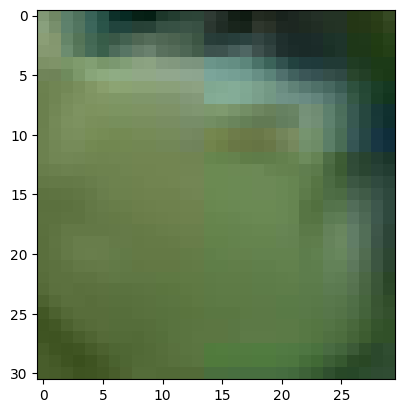

yolo predicted class: 2 (34.68) classifier: 2 (96.27)


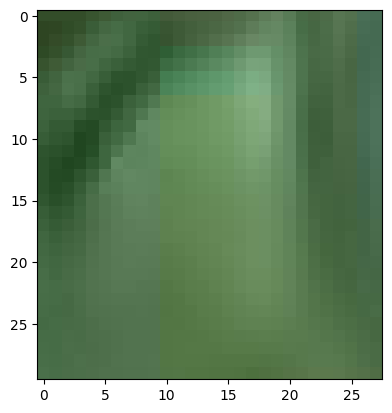

yolo predicted class: 2 (32.37) classifier: 2 (86.33)


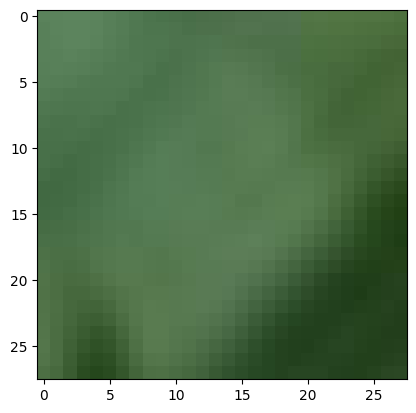

yolo predicted class: 2 (32.30) classifier: 2 (99.88)


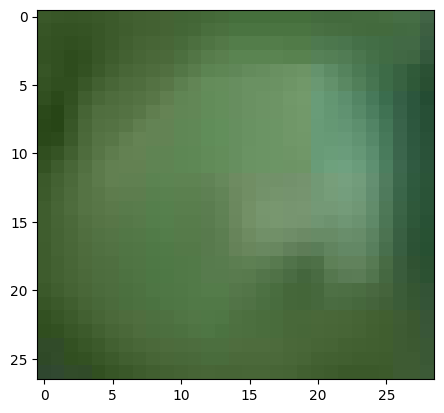

yolo predicted class: 2 (31.92) classifier: 2 (96.85)


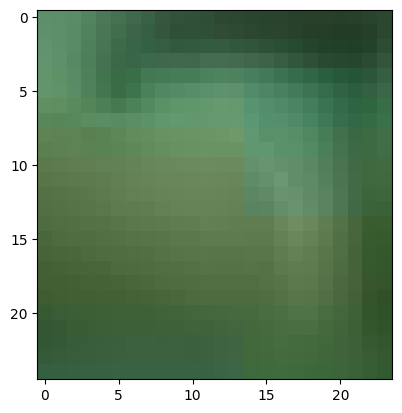

yolo predicted class: 2 (29.34) classifier: 2 (96.20)


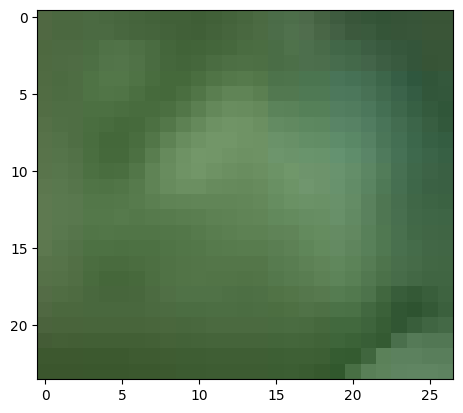

yolo predicted class: 2 (28.37) classifier: 2 (93.53)


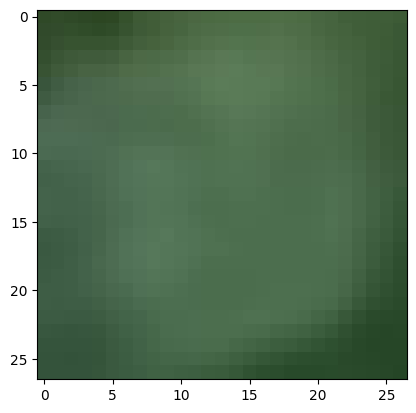

yolo predicted class: 2 (27.55) classifier: 2 (98.42)


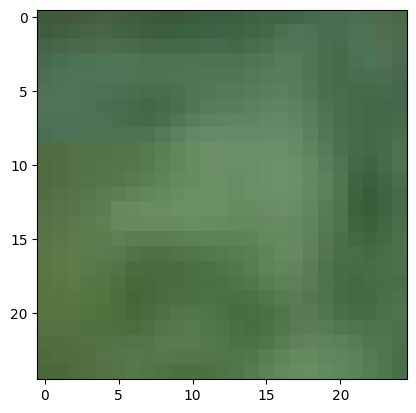

yolo predicted class: 2 (26.45) classifier: 2 (99.76)


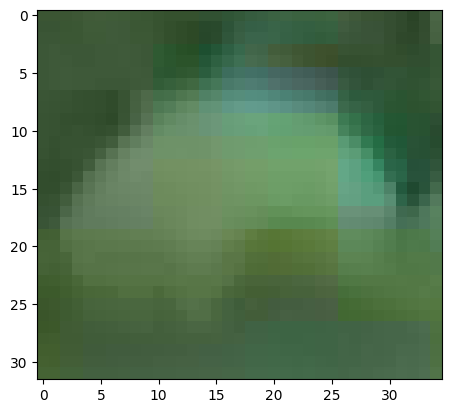

yolo predicted class: 2 (25.69) classifier: 1 (58.96)


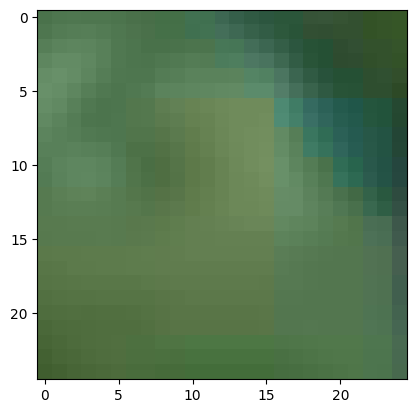

In [93]:
# @dataclass
# class BBox:
#   # cls_name: str
#   cls: int # index
#   conf: float
#   x1: float
#   y1: float
#   x2: float
#   y2: float

results = detector(tst_img)
result = results[0] # for 1 image
boxes = result.boxes
img = result.orig_img # IMPORTANT: np.array (H,W,3) in BGR, but classifier from PIL expects RGB!! 
num_boxes = boxes.shape[0]
print(f"number of Detections: {num_boxes}")

# for box, conf, cls_id in islice(zip(boxes.xyxy, boxes.conf, boxes.cls), 5):
for box, conf, cls_id in zip(boxes.xyxy, boxes.conf, boxes.cls):
  x1, y1, x2, y2 = map(int, box.tolist())
  conf = float(conf)
  cls_id = int(cls_id)
  yolo_pred_label = result.names[cls_id]
  det_crop = img[y1:y2, x1:x2]
  det_crop = np.ascontiguousarray(det_crop[..., ::-1]) # BGR -> RGB
  det_crop_transformed = inference_transform(det_crop).unsqueeze(0).to(device)
  # print(det_crop_transformed.shape)

  with torch.no_grad():
    logits = classifier(det_crop_transformed).detach()
    classifier_probs = nn.Softmax()(logits) # (1, n_classes)
    classifier_pred = logits.argmax(dim=1).item()
    classifier_conf = classifier_probs[:, classifier_pred].item()
    # print(logits, classifier_pred, classifier_probs, classifier_conf)

  print(f"yolo predicted class: {cls_id} ({100*conf:2.2f}) classifier: {classifier_pred} ({100*classifier_conf:2.2f})")
  plt.imshow(det_crop)
  plt.show()


  # print(x1, y1, x2, y2, conf, cls_id, yolo_pred_label)
  # fig, ax = plt.subplots(1, 2, figsize=(10, 7))
  # ax[0].imshow(det_crop)
  # ax[0].set_title("BGR")
  # ax[0].axis("off")
  # ax[1].imshow(det_crop2)
  # ax[1].set_title("RGB")
  # ax[1].axis("off")
  # plt.show()
  # plt.imshow(det_crop_transformed.permute(1,2,0))
  # plt.show()

In [ ]:
det_crop_transformed.shape

torch.Size([3, 64, 64])

In [64]:
classifier(det_crop_transformed.to(device))

RuntimeError: permute(sparse_coo): number of dimensions in the tensor input does not match the length of the desired ordering of dimensions i.e. input.dim() = 3 is not equal to len(dims) = 4